# Rank Tests for Multiple Groups: Kruskal-Wallis and Dunn's Post-Hoc

## Overview

The Kruskal-Wallis test is the nonparametric analog of the one-way ANOVA. It tests whether the distributions of three or more independent groups are identical, using ranks rather than raw values.

| Component | Detail |
|---|---|
| **Kruskal-Wallis H** | Omnibus test — significant result only indicates *some* group difference exists |
| **Dunn's test** | Post-hoc pairwise comparisons following a significant Kruskal-Wallis; uses rank sums and corrects for multiple comparisons |
| **Effect size: η²_H** | Eta-squared from H statistic; 0.01 = small, 0.06 = medium, 0.14 = large |
| **Friedman test** | Nonparametric analog of repeated-measures ANOVA — for blocked / matched designs |

## Kruskal-Wallis vs. One-Way ANOVA

| | Kruskal-Wallis | One-Way ANOVA |
|---|---|---|
| Assumption | Distributions identical under H₀; independent samples | Normality within groups; equal variance; independent samples |
| Input | Ranks | Raw values |
| Power | Lower when ANOVA assumptions hold | Higher when assumptions hold |
| Robustness | Robust to non-normality, outliers | Moderate robustness for large n |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(dunn.test)    # dunn.test() — fast, multiple correction built-in
library(rstatix)      # kruskal_test(), dunn_test() — tidy output
library(effectsize)   # rank_epsilon_squared(), eta_squared()
library(ggpubr)

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'dunn.test' was built under R version 4.4.3"
Warning message:
"package 'rstatix' was built under R version 

## Data

We simulate benthic invertebrate richness across four habitat types — skewed count-like data where normality and equal variance are implausible.

In [2]:
n_per <- 20
richness_data <- tibble(
  richness = c(
    MASS::rnegbin(n_per, mu = 18, theta = 2),   # reference
    MASS::rnegbin(n_per, mu =  7, theta = 1),   # degraded
    MASS::rnegbin(n_per, mu = 12, theta = 2),   # restored
    MASS::rnegbin(n_per, mu = 15, theta = 2)    # pristine
  ),
  habitat = factor(
    rep(c("reference", "degraded", "restored", "pristine"), each = n_per),
    levels = c("pristine", "reference", "restored", "degraded")
  )
)

# ── Descriptive statistics ────────────────────────────────────────────────────
richness_data %>%
  group_by(habitat) %>%
  summarise(
    n      = n(),
    median = median(richness),
    mean   = round(mean(richness), 1),
    iqr    = IQR(richness),
    sd     = round(sd(richness), 1)
  )

habitat,n,median,mean,iqr,sd
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
pristine,20,12.5,15.3,18.75,11.6
reference,20,17.0,18.7,22.50,13.2
restored,20,9.0,12.3,9.50,10.9
degraded,20,5.5,7.1,7.75,7.0


---

## Visualization

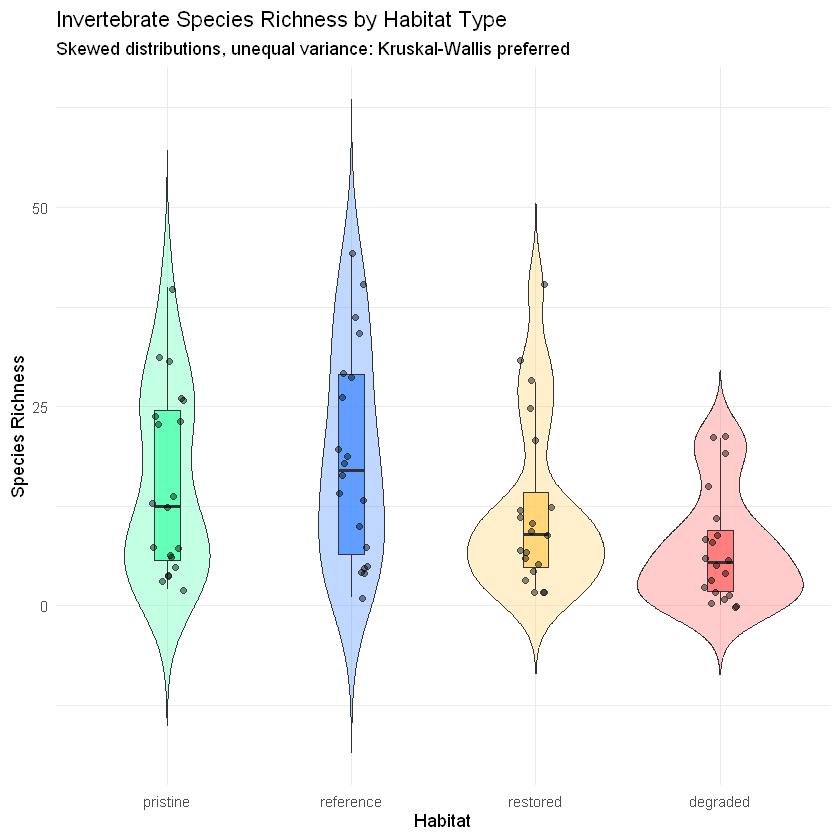

In [3]:
pal <- c(pristine = "#4fffb0", reference = "#4a8fff",
         restored = "#ffd166", degraded  = "#ff6b6b")

ggplot(richness_data, aes(x = habitat, y = richness, fill = habitat)) +
  geom_violin(alpha = 0.35, trim = FALSE) +
  geom_boxplot(width = 0.14, outlier.shape = NA, alpha = 0.8) +
  geom_jitter(width = 0.09, alpha = 0.45, size = 1.6) +
  scale_fill_manual(values = pal) +
  labs(
    title    = "Invertebrate Species Richness by Habitat Type",
    subtitle = "Skewed distributions, unequal variance: Kruskal-Wallis preferred",
    x = "Habitat", y = "Species Richness"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

---

## Kruskal-Wallis Test

In [4]:
# ── Base R: kruskal.test() ────────────────────────────────────────────────────
kw <- kruskal.test(richness ~ habitat, data = richness_data)
print(kw)
# H: Kruskal-Wallis chi-squared statistic
# df: k - 1 (number of groups minus 1)
# p-value: omnibus significance

# ── Effect size: eta-squared (η²_H) ──────────────────────────────────────────
# η²_H = (H - k + 1) / (n - k)    where k = number of groups, n = total N
k_groups <- nlevels(richness_data$habitat)
n_total  <- nrow(richness_data)
eta_sq_H <- (kw$statistic - k_groups + 1) / (n_total - k_groups)
cat(sprintf("\nη²_H = %.4f (small=.01, medium=.06, large=.14)\n", eta_sq_H))

# Alternative via effectsize package
effectsize::rank_epsilon_squared(richness ~ habitat, data = richness_data)


	Kruskal-Wallis rank sum test

data:  richness by habitat
Kruskal-Wallis chi-squared = 11.368, df = 3, p-value = 0.009895


η²_H = 0.1101 (small=.01, medium=.06, large=.14)


rank_epsilon_squared,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
0.1438946,0.95,0.06206122,1


---

## Dunn's Post-Hoc Test

Run only after a significant Kruskal-Wallis. Dunn's test uses the rank sums from the overall test, maintains the correct reference distribution, and applies a multiple comparison correction.

In [9]:
# ── Dunn's test via dunn.test package ─────────────────────────────────────────
# method options: "bonferroni", "BH" (Benjamini-Hochberg), "holm", "none"
dunn_result <- dunn.test::dunn.test(
  richness_data$richness,
  richness_data$habitat,
  method = "BH",     # FDR correction — less conservative than Bonferroni
  alpha  = 0.05,
  kw     = TRUE,     # print Kruskal-Wallis first
  label  = TRUE      # print group labels
)

# ── Tidy version via rstatix ──────────────────────────────────────────────────
dunn_tidy <- rstatix::dunn_test(
  richness_data,
  richness ~ habitat,
  p.adjust.method = "BH"
)
print(dunn_tidy)
# group1, group2: the two groups being compared
# statistic: Z statistic for this pair
# p: raw p-value
# p.adj: BH-corrected p-value
# p.adj.signif: significance stars

# ── Effect size for each pair: rank-biserial r ────────────────────────────────
pairs <- combn(levels(richness_data$habitat), 2, simplify = FALSE)
pairwise_r <- map_dfr(pairs, function(p) {
  sub_data <- richness_data %>%
    dplyr::filter(habitat %in% p) %>%
    dplyr::mutate(habitat = droplevels(factor(habitat)))
  rb <- effectsize::rank_biserial(richness ~ habitat, data = sub_data)  # renamed to rb
  tibble(pair    = paste(p, collapse = " vs. "),
         r       = round(rb$r_rank_biserial, 3),
         ci_low  = round(rb$CI_low,  3),
         ci_high = round(rb$CI_high, 3))
})
print(pairwise_r)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 11.3677, df = 3, p-value = 0.01


                   Dunn's Pairwise Comparison of x by group                   
                             (Benjamini-Hochberg)                             
Col Mean-│
Row Mean │   degraded   pristine   referenc
─────────┼─────────────────────────────────
pristine │  -2.499668
         │     0.0186*
         │


referenc │  -3.197805  -0.698136
         │     0.0042*    0.2425 
         │
restored │  -1.699366   0.800302   1.498439
         │     0.0893     0.2541     0.1005 

α = 0.05
Reject Ho if p ≤ α/2, where p = Pr(Z ≥ |z|)


# A tibble: 6 × 9
  .y.      group1    group2      n1    n2 statistic       p   p.adj p.adj.signif
* <chr>    <chr>     <chr>    <int> <int>     <dbl>   <dbl>   <dbl> <chr>       
1 richness pristine  referen…    20    20     0.698 0.485   0.485   ns          
2 richness pristine  restored    20    20    -0.800 0.424   0.485   ns          
3 richness pristine  degraded    20    20    -2.50  0.0124  0.0373  *           
4 richness reference restored    20    20    -1.50  0.134   0.201   ns          
5 richness reference degraded    20    20    -3.20  0.00138 0.00831 **          
6 richness restored  degraded    20    20    -1.70  0.0893  0.179   ns          
# A tibble: 6 × 4
  pair                        r ci_low ci_high
  <chr>                   <dbl>  <dbl>   <dbl>
1 pristine vs. reference -0.147 -0.471   0.211
2 pristine vs. restored   0.155 -0.203   0.477
3 pristine vs. degraded   0.47   0.147   0.703
4 reference vs. restored  0.3   -0.053   0.586
5 reference vs. degraded  0.542  0

---

## Adding Significance Brackets to Plots

Warning message in wilcox.test.default(c(7, 26, 3, 4, 4, 6, 6, 31, 12, 13, 31, 2, :
"cannot compute exact p-value with ties"
Warning message in wilcox.test.default(c(34, 7, 13, 1, 14, 5, 40, 20, 4, 4, 26, :
"cannot compute exact p-value with ties"


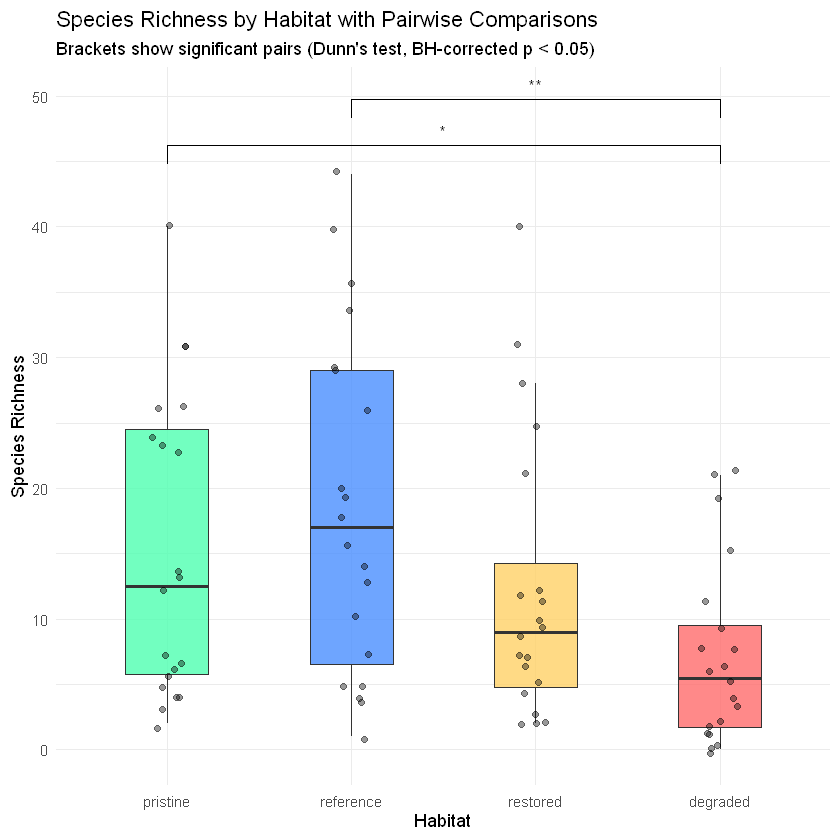

In [10]:
# ── Identify significant pairs after correction ───────────────────────────────
sig_pairs <- dunn_tidy %>%
  filter(p.adj < 0.05) %>%
  select(group1, group2, p.adj.signif)

# ── ggpubr: add significance brackets ────────────────────────────────────────
ggplot(richness_data, aes(x = habitat, y = richness, fill = habitat)) +
  geom_boxplot(width = 0.45, outlier.shape = NA, alpha = 0.8) +
  geom_jitter(width = 0.1, alpha = 0.4, size = 1.5) +
  ggpubr::stat_compare_means(
    comparisons = lapply(1:nrow(sig_pairs), function(i)
                         c(sig_pairs$group1[i], sig_pairs$group2[i])),
    method      = "wilcox.test",
    label       = "p.signif",
    step.increase = 0.08
  ) +
  scale_fill_manual(values = pal) +
  labs(
    title    = "Species Richness by Habitat with Pairwise Comparisons",
    subtitle = "Brackets show significant pairs (Dunn's test, BH-corrected p < 0.05)",
    x = "Habitat", y = "Species Richness"
  ) +
  theme_minimal() + theme(legend.position = "none")

---

## Friedman Test: Nonparametric Repeated-Measures ANOVA

In [11]:
# ── Simulate: same 15 sites assessed at 3 time points ────────────────────────
n_sites <- 15
friedman_data <- tibble(
  site  = rep(paste0("site", 1:n_sites), 3),
  time  = factor(rep(c("baseline", "year1", "year3"), each = n_sites),
                 levels = c("baseline", "year1", "year3")),
  score = c(
    round(runif(n_sites, 3, 6)),
    round(runif(n_sites, 4, 7)),
    round(runif(n_sites, 5, 9))
  )
)

# friedman.test() requires a matrix: rows = subjects, columns = conditions
friedman_mat <- friedman_data %>%
  pivot_wider(names_from = time, values_from = score) %>%
  select(-site) %>%
  as.matrix()

friedman_result <- friedman.test(friedman_mat)
print(friedman_result)

# ── Post-hoc: Conover-Iman test for repeated measures ────────────────────────
# install.packages("PMCMRplus")
# PMCMRplus::frdAllPairsConoverTest(friedman_mat, p.adjust.method = "BH")


	Friedman rank sum test

data:  friedman_mat
Friedman chi-squared = 8.4444, df = 2, p-value = 0.01467



---

## Reporting Results

In [12]:
cat(sprintf("Kruskal-Wallis: H(%d) = %.2f, p = %.4f, η²_H = %.3f\n",
            kw$parameter, kw$statistic, kw$p.value, eta_sq_H))

# Standard reporting format:
# "Species richness differed significantly among habitat types
#  (Kruskal-Wallis: H(3) = XX.XX, p = .XXX, η²_H = .XX).
#  Dunn's post-hoc tests (BH-corrected) indicated that degraded sites had
#  significantly lower richness than all other habitat types (all p_adj < .05),
#  while pristine and reference sites did not differ (Z = X.XX, p_adj = .XXX)."
#
# Always report: H statistic, df, p, effect size η²_H
# Always apply and report multiple comparison correction for post-hoc tests
# Report median (IQR) as descriptive statistics, not mean (SD)

Kruskal-Wallis: H(3) = 11.37, p = 0.0099, η²_H = 0.110


---

## Common Pitfalls

**1. Running pairwise Mann-Whitney tests instead of Kruskal-Wallis + Dunn's**  
Running all pairwise Mann-Whitney tests directly (without Kruskal-Wallis first) does not use a shared rank reference and inflates type I error. Use Kruskal-Wallis as the omnibus test, then Dunn's post-hoc which uses the correct rank sums from the full dataset.

**2. Not correcting for multiple comparisons in post-hoc tests**  
With k groups, there are k(k-1)/2 pairwise comparisons. Always correct — Bonferroni is conservative; BH (Benjamini-Hochberg) is preferred when the number of comparisons is large.

**3. Reporting means instead of medians**  
If the Kruskal-Wallis is used because of non-normality, report median and IQR as descriptive statistics — not mean and SD. Reporting means alongside a nonparametric test is inconsistent.

**4. Not reporting effect size**  
Always compute and report η²_H (overall) and rank-biserial r (pairwise) alongside p-values. A significant H with small effect size may not be ecologically meaningful.

**5. Using Kruskal-Wallis for blocked or repeated-measures designs**  
Kruskal-Wallis assumes independent samples. For repeated measures or matched designs, use the Friedman test.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*